In [1]:
# Import core data manipulation and visualization libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import the dataset required for Question 1
from sklearn.datasets import fetch_california_housing

# Set aesthetic parameters for our plots
sns.set_theme(style="whitegrid")

# 1. Reproducibility: Set global random seeds
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# 2. Load the California Housing dataset
print("Loading California Housing Dataset...")
california = fetch_california_housing(as_frame=True)
df = california.frame

# 3. Initial Data Inspection
print(f"\nDataset Shape: {df.shape}")
print("\n--- Data Types and Missing Values ---")
print(df.info())

print("\n--- Summary Statistics ---")
display(df.describe())

Loading California Housing Dataset...

Dataset Shape: (20640, 9)

--- Data Types and Missing Values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

--- Summary Statistics ---


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


Generating Feature Distributions...


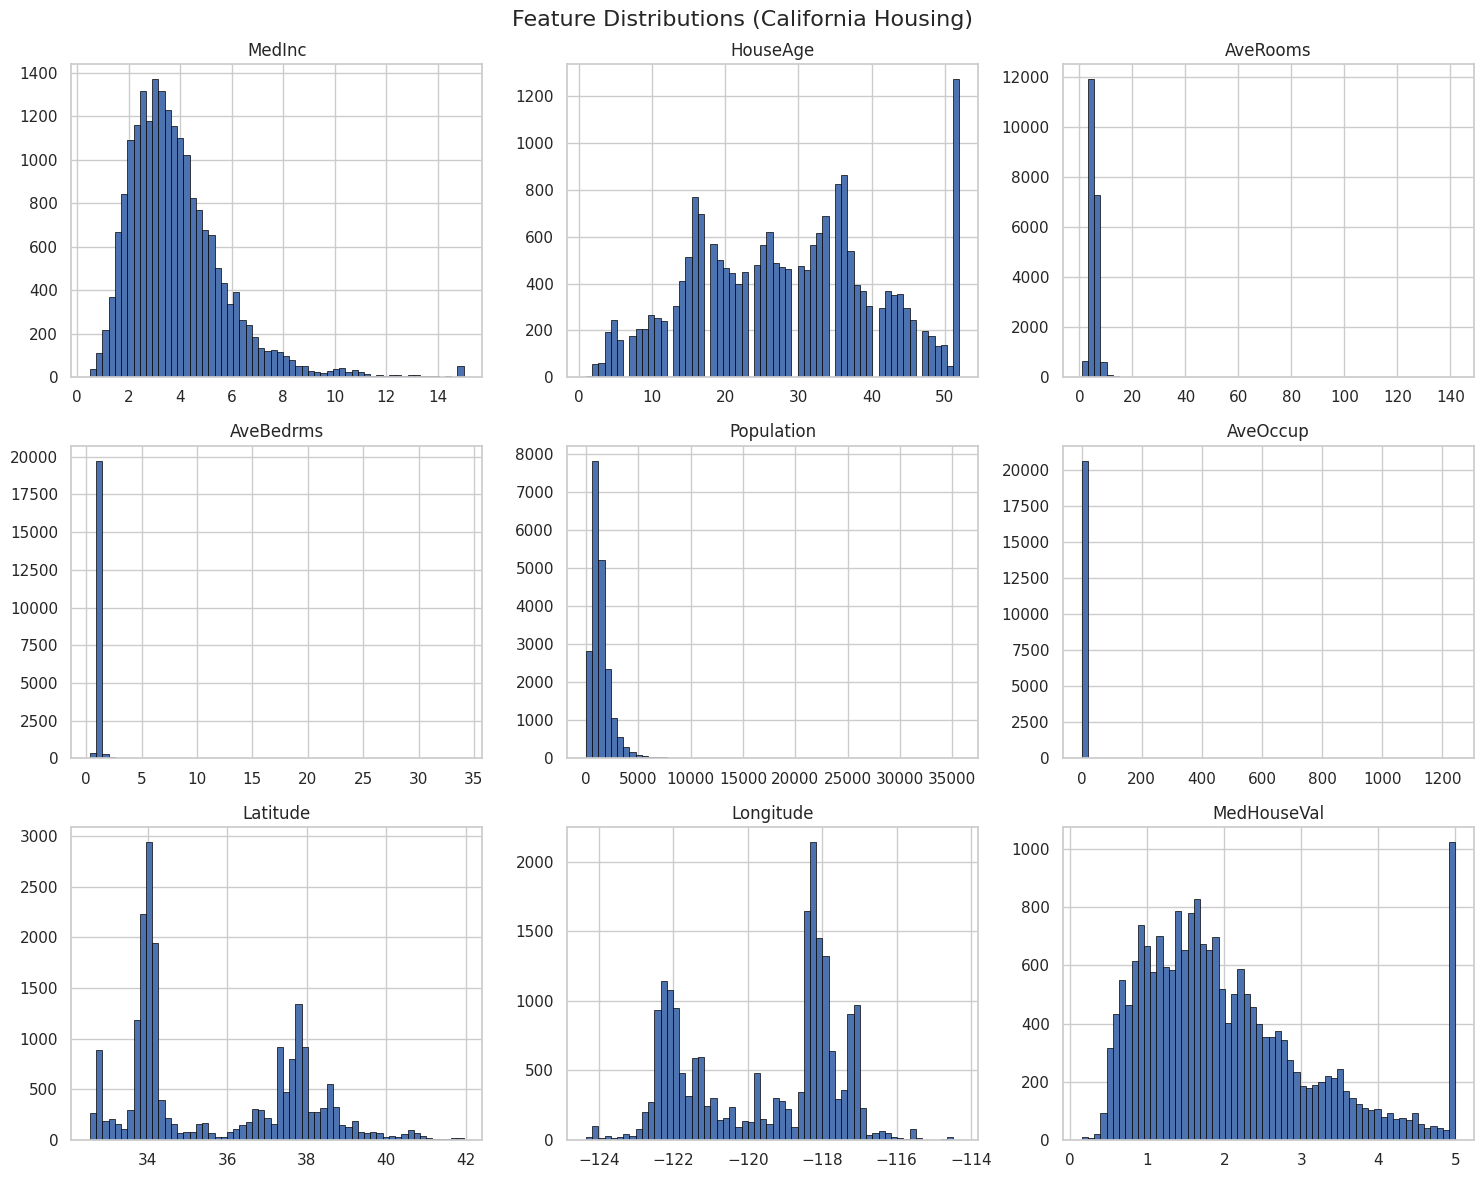


Generating Correlation Heatmap...


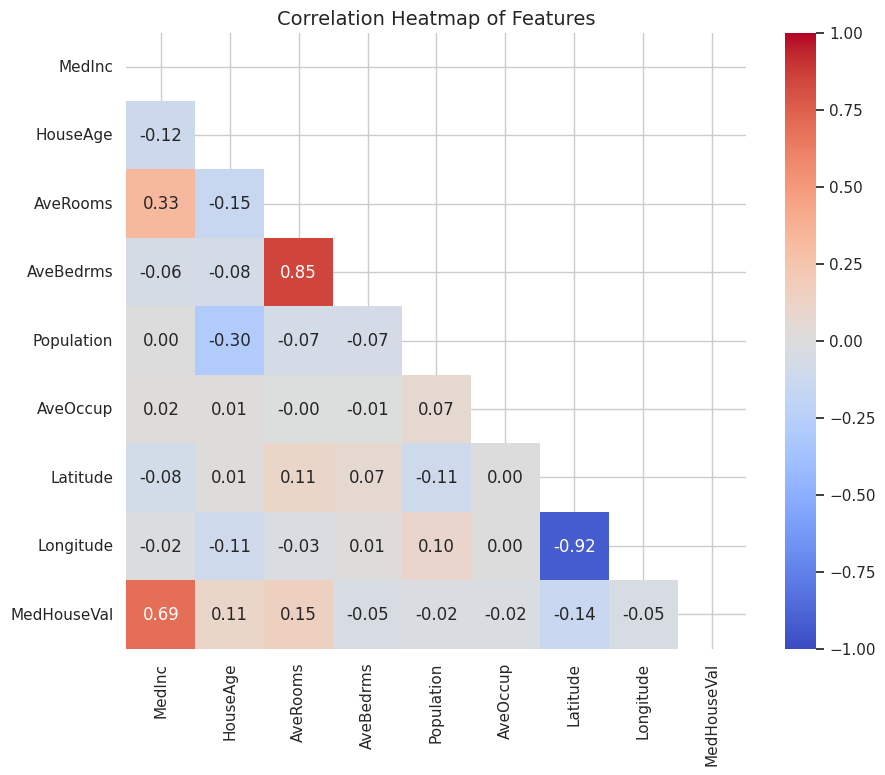


--- Outlier Detection (IQR Method) ---
MedInc      :  681 outliers (3.30%)
AveRooms    :  511 outliers (2.48%)
AveBedrms   : 1424 outliers (6.90%)
Population  : 1196 outliers (5.79%)
AveOccup    :  711 outliers (3.44%)


In [2]:
# 4. Exploratory Data Analysis (EDA)

# 4a. Feature Distributions (Histograms)
print("Generating Feature Distributions...")
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
df.hist(bins=60, ax=axes, edgecolor='black', linewidth=0.5)
plt.suptitle("Feature Distributions (California Housing)", fontsize=16)
plt.tight_layout()
plt.show()

# 4b. Correlation Heatmap
print("\nGenerating Correlation Heatmap...")
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
# Using a mask to hide the upper triangle makes it look more academic!
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Heatmap of Features", fontsize=14)
plt.show()

# 4c. Outlier Detection using IQR
print("\n--- Outlier Detection (IQR Method) ---")
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count how many data points fall outside the bounds
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers)

# Let's check the features most likely to have severe outliers
features_to_check = ['MedInc', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']
for feature in features_to_check:
    num_outliers = detect_outliers_iqr(df, feature)
    percentage = (num_outliers / len(df)) * 100
    print(f"{feature: <12}: {num_outliers: >4} outliers ({percentage:.2f}%)")

In [3]:
# 5. Feature Engineering and Selection
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
import numpy as np

print("Starting Feature Engineering...")

# 5a. Log Transforms for skewed features and the target
# We use log1p (log(1 + x)) to safely handle any zero values
features_to_log = ['AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'MedInc']
for feat in features_to_log:
    df[f'Log_{feat}'] = np.log1p(df[feat])

X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']
# The assignment asks for log transforms for skewed targets
y_log = np.log1p(y)

# 5b. Polynomial and Interaction Terms (Degrees 2 and 3)
# We will apply this to a subset to avoid an explosion of dimensions
poly_features = ['MedInc', 'HouseAge', 'Latitude', 'Longitude']
poly = PolynomialFeatures(degree=3, interaction_only=False, include_bias=False)
X_poly = poly.fit_transform(X[poly_features])

# Retrieve the new feature names
poly_feature_names = poly.get_feature_names_out(poly_features)
X_poly_df = pd.DataFrame(X_poly, columns=poly_feature_names, index=X.index)

# Combine our log-transformed data with our new polynomial features
X_engineered = pd.concat([X.drop(poly_features, axis=1), X_poly_df], axis=1)

# 5c. Feature Selection using Tree-based feature importance
print("\nSelecting top features using Random Forest importance...")
# We use a quick Random Forest to evaluate which engineered features actually matter
rf = RandomForestRegressor(n_estimators=50, random_state=RANDOM_SEED, n_jobs=-1)
rf.fit(X_engineered, y_log)

# Keep features that have an importance higher than the median
selector = SelectFromModel(rf, prefit=True, threshold='median')
X_selected = selector.transform(X_engineered)
selected_feature_names = X_engineered.columns[selector.get_support()]

# Create our final, optimized feature set
X_final = pd.DataFrame(X_selected, columns=selected_feature_names, index=X.index)

print(f"Original feature count: {X.shape[1]}")
print(f"Engineered feature count before selection: {X_engineered.shape[1]}")
print(f"Final feature count after selection: {X_final.shape[1]}")

print("\n--- Top 10 Selected Features by Importance ---")
importances = pd.Series(rf.feature_importances_, index=X_engineered.columns).sort_values(ascending=False)
display(importances.head(10))

Starting Feature Engineering...

Selecting top features using Random Forest importance...
Original feature count: 13
Engineered feature count before selection: 43
Final feature count after selection: 22

--- Top 10 Selected Features by Importance ---


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


,0
MedInc^2 HouseAge,0.338561
MedInc Longitude^2,0.082185
Log_AveOccup,0.052350
MedInc^2 Longitude,0.044842
AveOccup,0.043544
Longitude^2,0.036984
Latitude,0.026121
Longitude,0.025907
MedInc Longitude,0.024932
Latitude^2,0.024904


In [4]:
# 6. Model Selection and Evaluation
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from xgboost import XGBRegressor
from sklearn.model_selection import RepeatedKFold, cross_validate, RandomizedSearchCV
import warnings

# Suppress convergence warnings from Lasso/ElasticNet for cleaner output
warnings.filterwarnings("ignore")

print("Step A: Tuning XGBoost Hyperparameters...")
# 6a. Hyperparameter optimization for XGBoost using Randomized Search
xgb_base = XGBRegressor(random_state=RANDOM_SEED, objective='reg:squarederror')
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

# We use a standard 3-fold CV just for the quick tuning phase
random_search = RandomizedSearchCV(
    xgb_base, param_distributions=param_grid, n_iter=5,
    scoring='neg_root_mean_squared_error', cv=3, random_state=RANDOM_SEED, n_jobs=-1
)
random_search.fit(X_final, y_log)
best_xgb = random_search.best_estimator_
print(f"Best XGBoost Parameters: {random_search.best_params_}")

# 6b. Define all models for the final comparison
models = {
    'Linear Regression': LinearRegression(),
    'Ridge (CV)': RidgeCV(alphas=np.logspace(-3, 3, 10)),
    'Lasso (CV)': LassoCV(alphas=np.logspace(-3, 1, 10), random_state=RANDOM_SEED, max_iter=5000),
    'Elastic Net (CV)': ElasticNetCV(l1_ratio=[0.1, 0.5, 0.9], alphas=np.logspace(-3, 1, 10), random_state=RANDOM_SEED, max_iter=5000),
    'XGBoost (Tuned)': best_xgb
}

# 6c. Set up Repeated K-Fold Cross Validation
print("\nStep B: Running 5-Fold CV (Repeated 3 times) for all models...")
rkf = RepeatedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_SEED)

# Define the metrics requested by the assignment
scoring_metrics = {
    'RMSE': 'neg_root_mean_squared_error',
    'MAE': 'neg_mean_absolute_error',
    'R2': 'r2',
    'MAPE': 'neg_mean_absolute_percentage_error',
    'ExpVar': 'explained_variance'
}

results_list = []
n_samples = len(X_final)
p_features = X_final.shape[1]

for name, model in models.items():
    print(f"Evaluating {name}...")
    cv_results = cross_validate(model, X_final, y_log, cv=rkf, scoring=scoring_metrics, n_jobs=-1)

    # Extract mean and std for standard metrics (flipping the negative signs scikit-learn uses)
    rmse_mean, rmse_std = -cv_results['test_RMSE'].mean(), cv_results['test_RMSE'].std()
    mae_mean, mae_std = -cv_results['test_MAE'].mean(), cv_results['test_MAE'].std()
    r2_mean, r2_std = cv_results['test_R2'].mean(), cv_results['test_R2'].std()
    mape_mean, mape_std = -cv_results['test_MAPE'].mean(), cv_results['test_MAPE'].std()
    expvar_mean, expvar_std = cv_results['test_ExpVar'].mean(), cv_results['test_ExpVar'].std()

    # Calculate Adjusted R2 manually using the mean R2
    adj_r2 = 1 - ((1 - r2_mean) * (n_samples - 1) / (n_samples - p_features - 1))

    results_list.append({
        'Model': name,
        'RMSE': f"{rmse_mean:.4f} ± {rmse_std:.4f}",
        'MAE': f"{mae_mean:.4f} ± {mae_std:.4f}",
        'R^2': f"{r2_mean:.4f} ± {r2_std:.4f}",
        'Adj R^2': f"{adj_r2:.4f}",
        'MAPE': f"{mape_mean:.4f} ± {mape_std:.4f}",
        'Expl Variance': f"{expvar_mean:.4f} ± {expvar_std:.4f}"
    })

# 6d. Display final results as a formatted DataFrame
results_df = pd.DataFrame(results_list)
print("\n--- Final Cross-Validation Results ---")
display(results_df)

Step A: Tuning XGBoost Hyperparameters...
Best XGBoost Parameters: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1}

Step B: Running 5-Fold CV (Repeated 3 times) for all models...
Evaluating Linear Regression...
Evaluating Ridge (CV)...
Evaluating Lasso (CV)...
Evaluating Elastic Net (CV)...
Evaluating XGBoost (Tuned)...

--- Final Cross-Validation Results ---


,Model,RMSE,MAE,R^2,Adj R^2,MAPE,Expl Variance
0,Linear Regression,0.2381 ± 0.1514,0.1472 ± 0.0047,0.3700 ± 1.2048,0.3693,0.1597 ± 0.0059,0.3702 ± 1.2040
1,Ridge (CV),5.0016 ± 3.4094,4.3640 ± 3.1368,-287.3128 ± 311.1543,-287.6205,4.6807 ± 3.3479,-287.2309 ± 311.1078
2,Lasso (CV),0.2256 ± 0.0908,0.1517 ± 0.0036,0.5326 ± 0.5529,0.5321,0.1648 ± 0.0041,0.5327 ± 0.5525
3,Elastic Net (CV),0.2207 ± 0.0734,0.1517 ± 0.0029,0.5728 ± 0.4062,0.5723,0.1648 ± 0.0035,0.5729 ± 0.4060
4,XGBoost (Tuned),0.1437 ± 0.0022,0.1022 ± 0.0015,0.8372 ± 0.0057,0.8370,0.1088 ± 0.0019,0.8372 ± 0.0057


Running Statistical Significance Tests...
Wilcoxon Signed-Rank Test (XGBoost vs Elastic Net):
Statistic: 11.0000, p-value: 1.0547e-01

Generating Residual Plots...


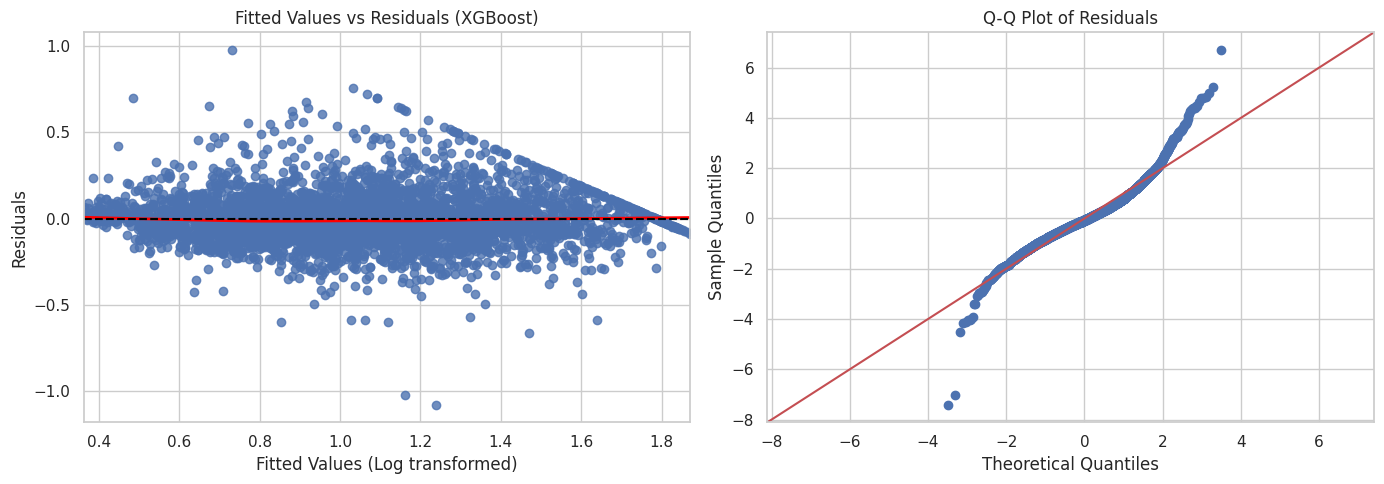


Evaluating HuberRegressor (Robust Regression)...
HuberRegressor Test R^2: 0.6594
HuberRegressor Test RMSE: 0.2072


In [5]:
# 7. Statistical Significance and Residual Analysis
from scipy.stats import wilcoxon
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.linear_model import HuberRegressor
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm

print("Running Statistical Significance Tests...")
# 7a. Wilcoxon Signed-Rank Test (XGBoost vs Elastic Net)
# We use cross_val_score to get the raw arrays of scores across 10 folds
xgb_scores = cross_val_score(best_xgb, X_final, y_log, cv=10, scoring='r2', n_jobs=-1)
enet = ElasticNetCV(l1_ratio=[0.1, 0.5, 0.9], alphas=np.logspace(-3, 1, 10), random_state=RANDOM_SEED)
enet_scores = cross_val_score(enet, X_final, y_log, cv=10, scoring='r2', n_jobs=-1)

# Perform the Wilcoxon test
stat, p_value = wilcoxon(xgb_scores, enet_scores)
print(f"Wilcoxon Signed-Rank Test (XGBoost vs Elastic Net):")
print(f"Statistic: {stat:.4f}, p-value: {p_value:.4e}")
if p_value < 0.05:
    print("Conclusion: The difference between XGBoost and Elastic Net is statistically significant.")

# 7b. Residual Analysis on the best model (XGBoost)
print("\nGenerating Residual Plots...")
X_train, X_test, y_train, y_test = train_test_split(X_final, y_log, test_size=0.2, random_state=RANDOM_SEED)
best_xgb.fit(X_train, y_train)
y_pred = best_xgb.predict(X_test)
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Fitted vs Residuals
sns.residplot(x=y_pred, y=residuals, lowess=True, ax=axes[0], line_kws={'color': 'red', 'lw': 2})
axes[0].set_title('Fitted Values vs Residuals (XGBoost)')
axes[0].set_xlabel('Fitted Values (Log transformed)')
axes[0].set_ylabel('Residuals')
axes[0].axhline(0, color='black', linestyle='--')

# Plot 2: Q-Q Plot
sm.qqplot(residuals, line='45', fit=True, ax=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()

# 7c. Robust Regression (HuberRegressor)
print("\nEvaluating HuberRegressor (Robust Regression)...")
# We scale the data first this time so it doesn't fail like Ridge!
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

huber = make_pipeline(StandardScaler(), HuberRegressor(epsilon=1.35))
huber.fit(X_train, y_train)
huber_pred = huber.predict(X_test)

huber_r2 = r2_score(y_test, huber_pred)
huber_rmse = np.sqrt(mean_squared_error(y_test, huber_pred))

print(f"HuberRegressor Test R^2: {huber_r2:.4f}")
print(f"HuberRegressor Test RMSE: {huber_rmse:.4f}")